# Telco Customer Churn

The goal of this project will be to predict which customers are likely to churn **and** explain why, so retention efforts can be targeted. Customer churn is the loss of customers. If we can predict customer churn in advance, we can try to implement tactics to try to prevent them from leaving the service and increase the customer base.

In [259]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
Path to dataset files: /kaggle/input/datasets/blastchar/telco-customer-churn


In [260]:
df=pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


Our list of independent variables, $X$ are:
- customerID
- gender
- SeniorCitizen
- Partner
- Dependents
- tenure
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges

and our dependent variable $y$ is
- Churn

Let us import the necessary Python libraries.

In [261]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,StratifiedKFold,cross_validate
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,roc_curve,f1_score,recall_score,precision_score)

from xgboost import XGBClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)
RANDOM_STATE=42

pd.set_option("display.max_columns",None)
pd.set_option("display.width",200)
pd.set_option("display.float_format",lambda x:"%.3f"%x)

In [262]:
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We see that the column `TotalCharges` is an object, so we have to convert it to a numeric value.

In [264]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [265]:
print("Missing values in TotalCharges:",df["TotalCharges"].isna().sum())
df.loc[df["TotalCharges"].isna(),["customerID","tenure","MonthlyCharges","TotalCharges"]]

Missing values in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.550,NaN
753,3115-CZMZD,0,20.250,NaN
936,5709-LVOEQ,0,80.850,NaN
1082,4367-NUYAO,0,25.750,NaN
1340,1371-DWPAZ,0,56.050,NaN
3331,7644-OMVMY,0,19.850,NaN
3826,3213-VVOLG,0,25.350,NaN
4380,2520-SGTTA,0,20.000,NaN
5218,2923-ARZLG,0,19.700,NaN
6670,4075-WKNIU,0,73.350,NaN


We can see that all the missing rows have `tenure` as $0$. So this means that these are new customers who haven't been billed yet, so `TotalCharges` was blank. So we can reasonably fill with $0$.

In [266]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Missing values in TotalCharges:",df["TotalCharges"].isna().sum())

Missing values in TotalCharges: 0


Now let us look at the dependent variable.

In [267]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No    0.735
Yes   0.265
Name: proportion, dtype: float64


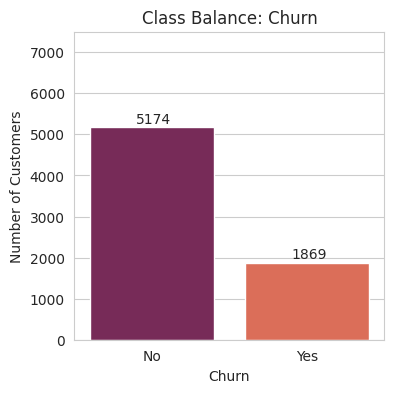

In [268]:
churn_rate=df["Churn"].value_counts(normalize=True)
print(churn_rate)

plt.figure(figsize=(4,4))
ax=sns.countplot(data=df,x="Churn",hue="Churn",palette="rocket")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.ylim(0,7500)
plt.title("Class Balance: Churn")
for p in ax.patches:
    ax.annotate((int(p.get_height())),(p.get_x()+0.30,p.get_height()+100))
plt.show()

We can see from this that around $73\%$ of customers did not churn and $27\%$ did. This is an imbalanced classification problem, meaning that a model that predicts "No" for everyone would be around $73\%$ accurate. So we cannot use accuracy as a metric alone as it would be misleading. In addition, when we split into train and validation sets, we should stratify on `Churn` so both sets keep a similar $73/27$ ratio.

## EDA

Let us perform some exploratory data analysis, ensuring we understand the data set and how each feature might affect the churn. We can divide the features into the following groups:
- Demographic: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- Service: `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`
- Account information (categorical): `Contract`, `PaperlessBilling`, `PaymentMethod`
- Account information (numerical): `tenure`, `MonthlyCharges`, `TotalCharges` 

In [269]:
d_feats=["gender","SeniorCitizen","Partner","Dependents"]
s_feats=["PhoneService","MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]
a_cat_feats=["Contract","PaperlessBilling","PaymentMethod"]
a_num_feats=["tenure","MonthlyCharges","TotalCharges"]

### Demographic Features

In [270]:
df_temp=df.copy()
if df_temp["Churn"].dtype=="object":
    df_temp["Churn_num"]=(df_temp["Churn"]=="Yes").astype(int)
else:
    df_temp["Churn_num"]=df_temp["Churn"]

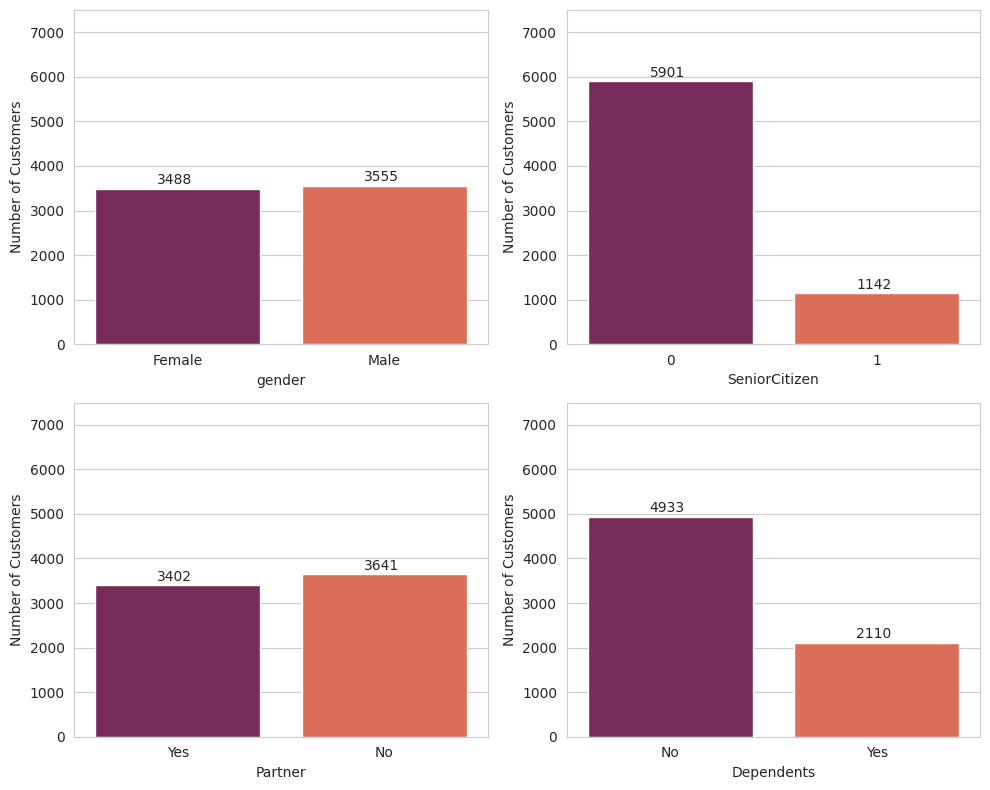

In [271]:
fig,axes=plt.subplots(2,2,figsize=(10,8))
for i,feat in enumerate(d_feats):
    ax=axes.flatten()[i]
    sns.countplot(data=df,x=feat,hue=feat,palette="rocket",legend=False,ax=ax)
    ax.set_xlabel(feat)
    ax.set_ylabel("Number of Customers")
    ax.set_ylim(0,7500)
    for p in ax.patches:
        ax.annotate((int(p.get_height())),(p.get_x()+0.30,p.get_height()+100))
plt.tight_layout()
plt.show()

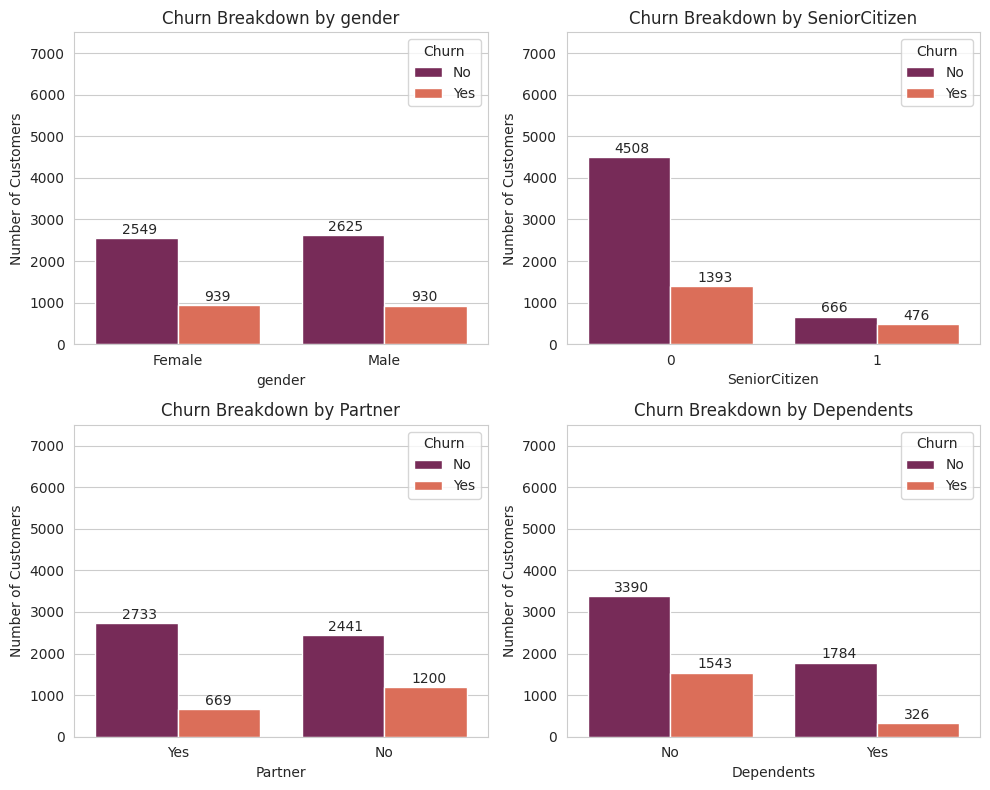

In [272]:
fig,axes=plt.subplots(2,2,figsize=(10,8))
for i,feat in enumerate(d_feats):
    ax=axes.flatten()[i]
    sns.countplot(data=df,x=feat,hue="Churn",palette="rocket",ax=ax)
    ax.set_xlabel(feat)
    ax.set_ylabel("Number of Customers")
    ax.set_ylim(0,7500)
    ax.set_title(f"Churn Breakdown by {feat}")
    for p in ax.patches:
        height=int(p.get_height())
        if height>0:
            ax.annotate((height),(p.get_x()+0.13,height+100))
plt.tight_layout()
plt.show()

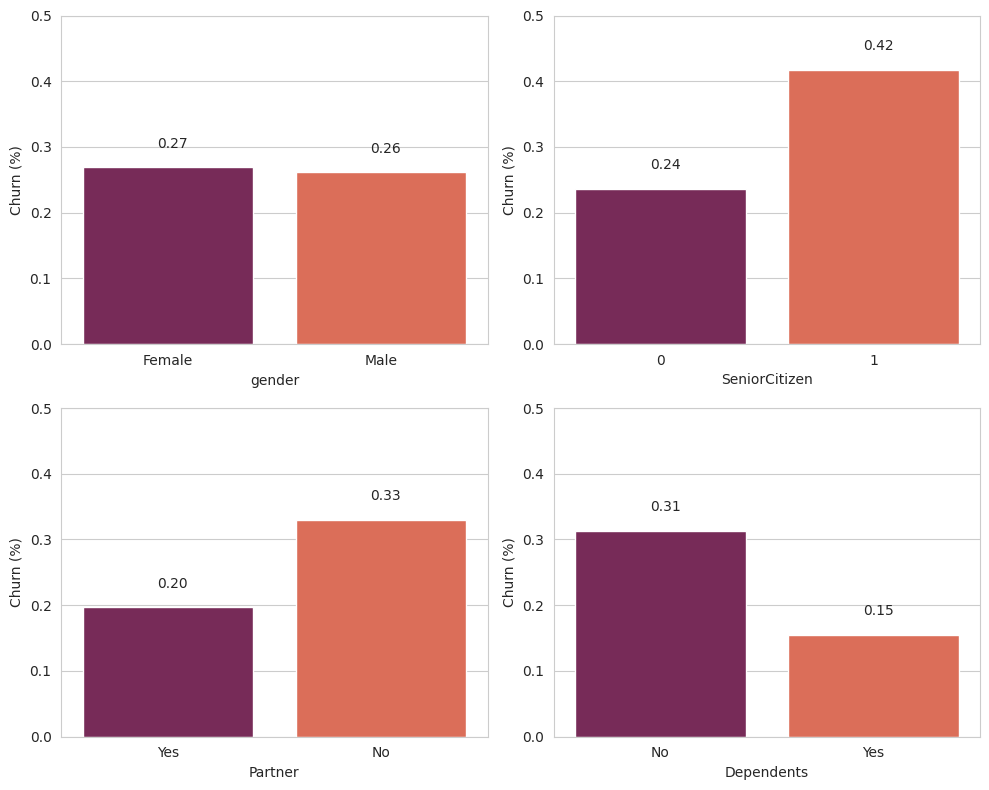

In [273]:
fig,axes=plt.subplots(2,2,figsize=(10,8))
for i,feat in enumerate(d_feats):
    ax=axes.flatten()[i]
    sns.barplot(data=df_temp,x=feat,y="Churn_num",hue=feat,palette="rocket",legend=False,ax=ax,errorbar=None)
    ax.set_xlabel(feat)
    ax.set_ylabel("Churn (%)")
    ax.set_ylim(0,0.5)
    for p in ax.patches:
        ax.annotate("%.2f" %(p.get_height()), (p.get_x()+0.35,p.get_height()+0.03))
plt.tight_layout()
plt.show()

From this we can see:
- Gender: there is not a significant difference in churn rate between men and women
- Senior Citizen: senior citizens are morelikely to churn
- Partner: single customers are more likely to churn than customers with partners
- Dependents: customers with dependents are less likely to churn than customers without any dependents

### Service Features

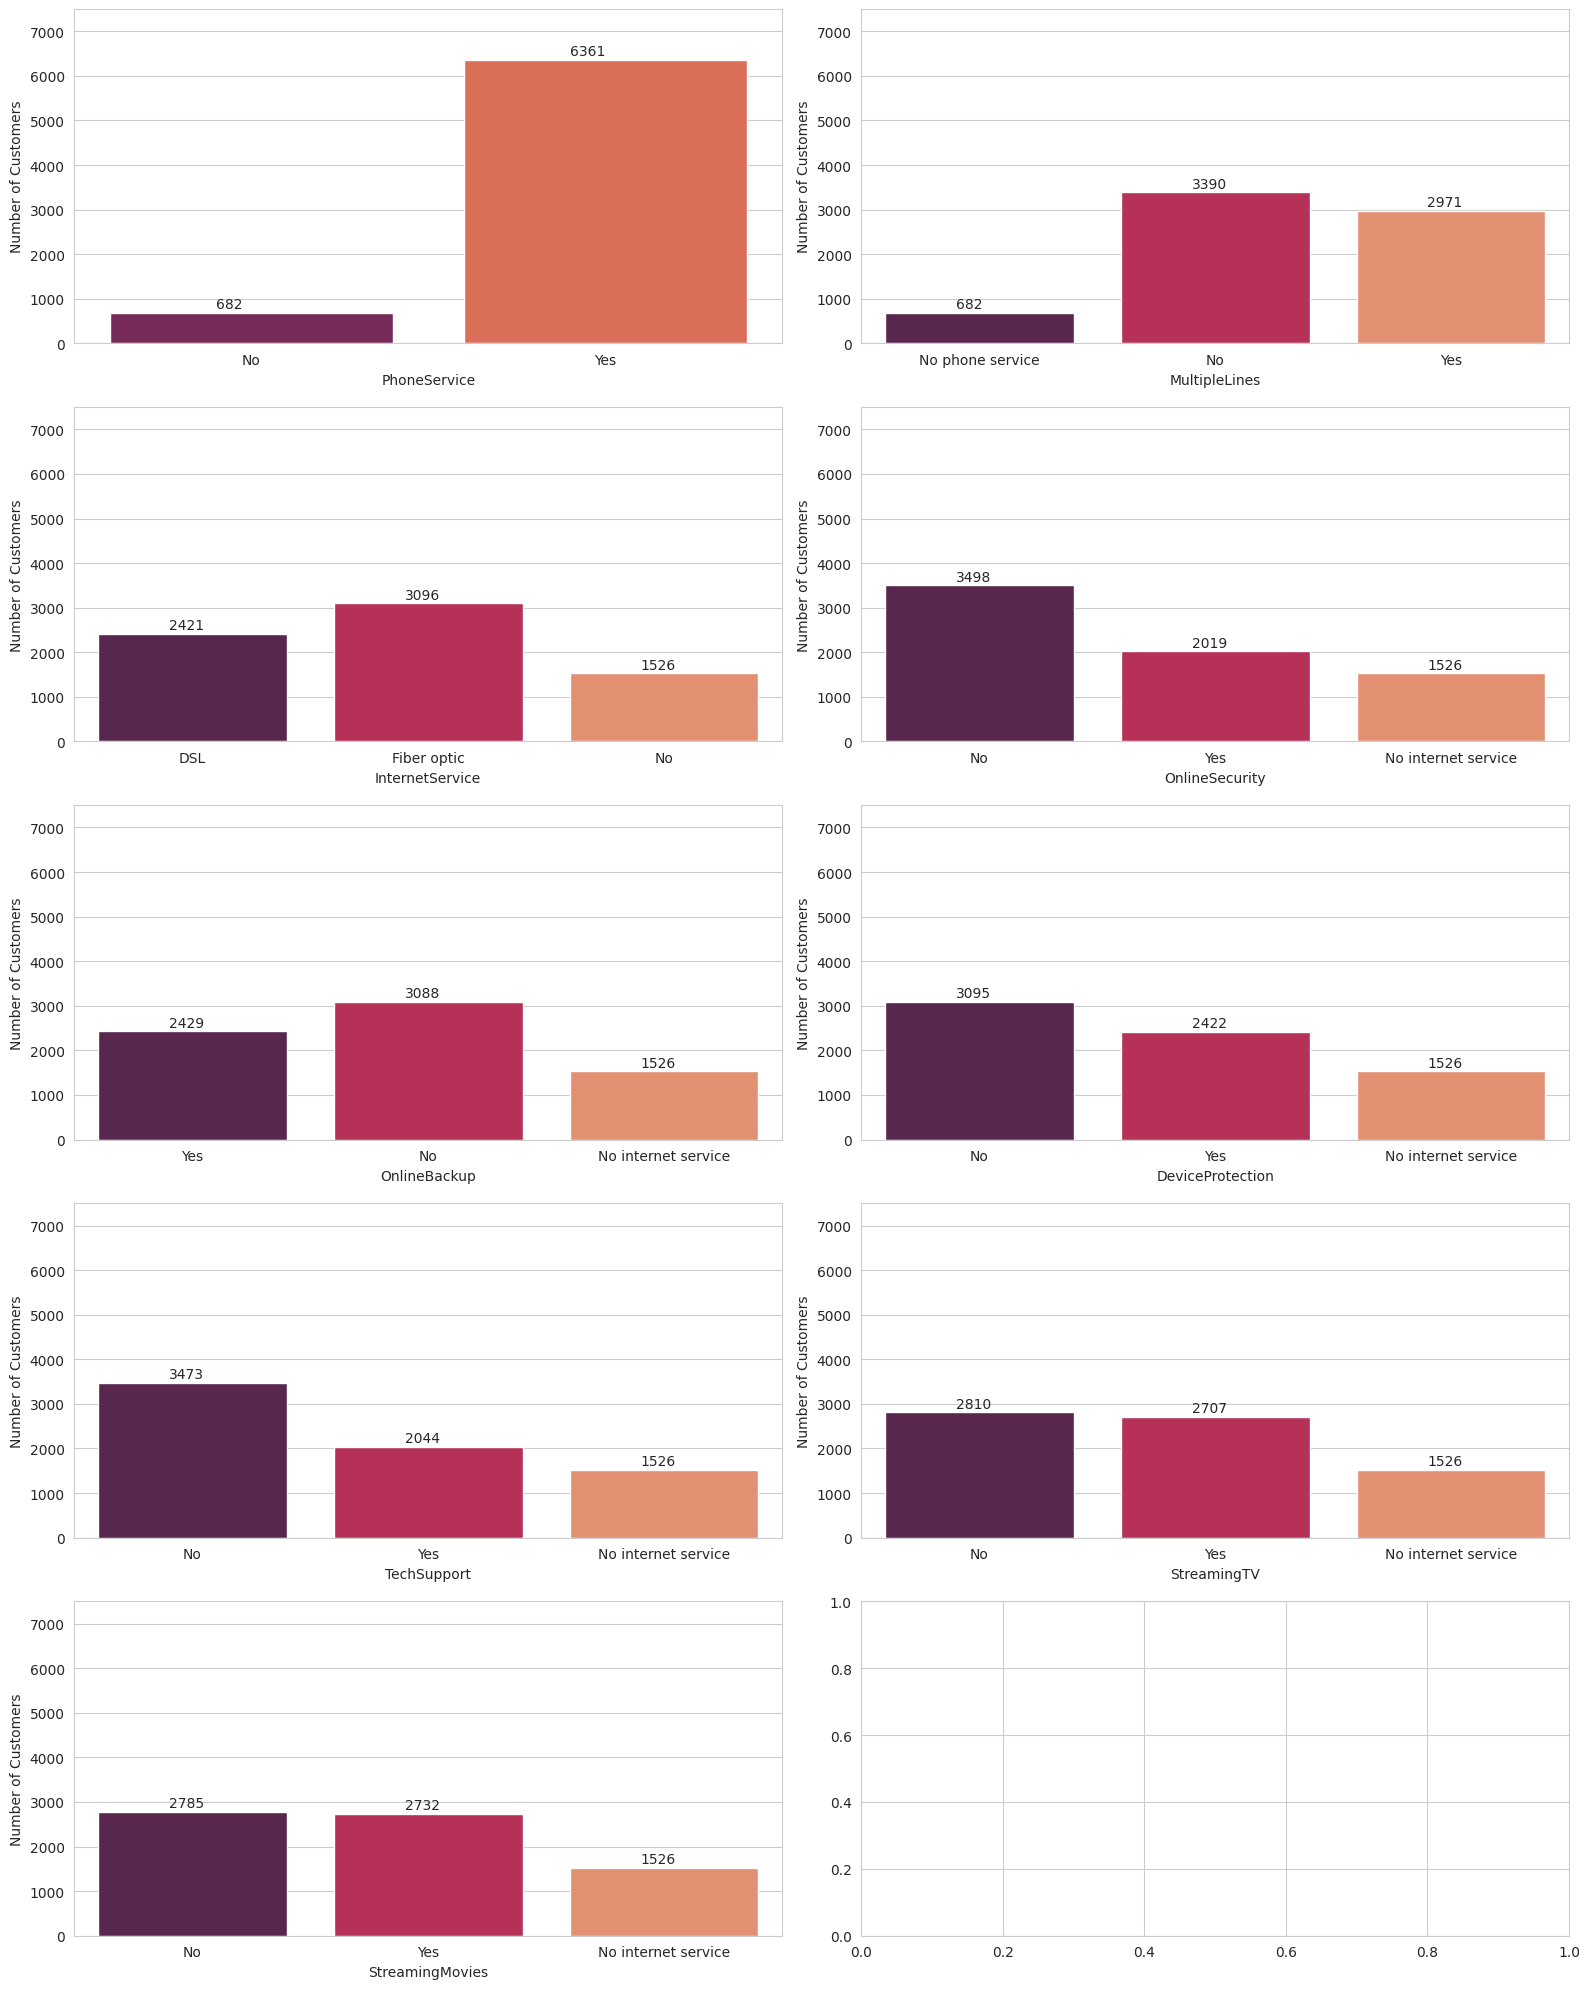

In [274]:
fig,axes=plt.subplots(5,2,figsize=(16,20))
for i,feat in enumerate(s_feats):
    ax=axes.flatten()[i]
    sns.countplot(data=df,x=feat,hue=feat,palette="rocket",legend=False,ax=ax)
    ax.set_xlabel(feat)
    ax.set_ylabel("Number of Customers")
    ax.set_ylim(0,7500)
    for p in ax.patches:
        ax.annotate((int(p.get_height())),(p.get_x()+0.30,p.get_height()+100))
plt.tight_layout()
plt.show()

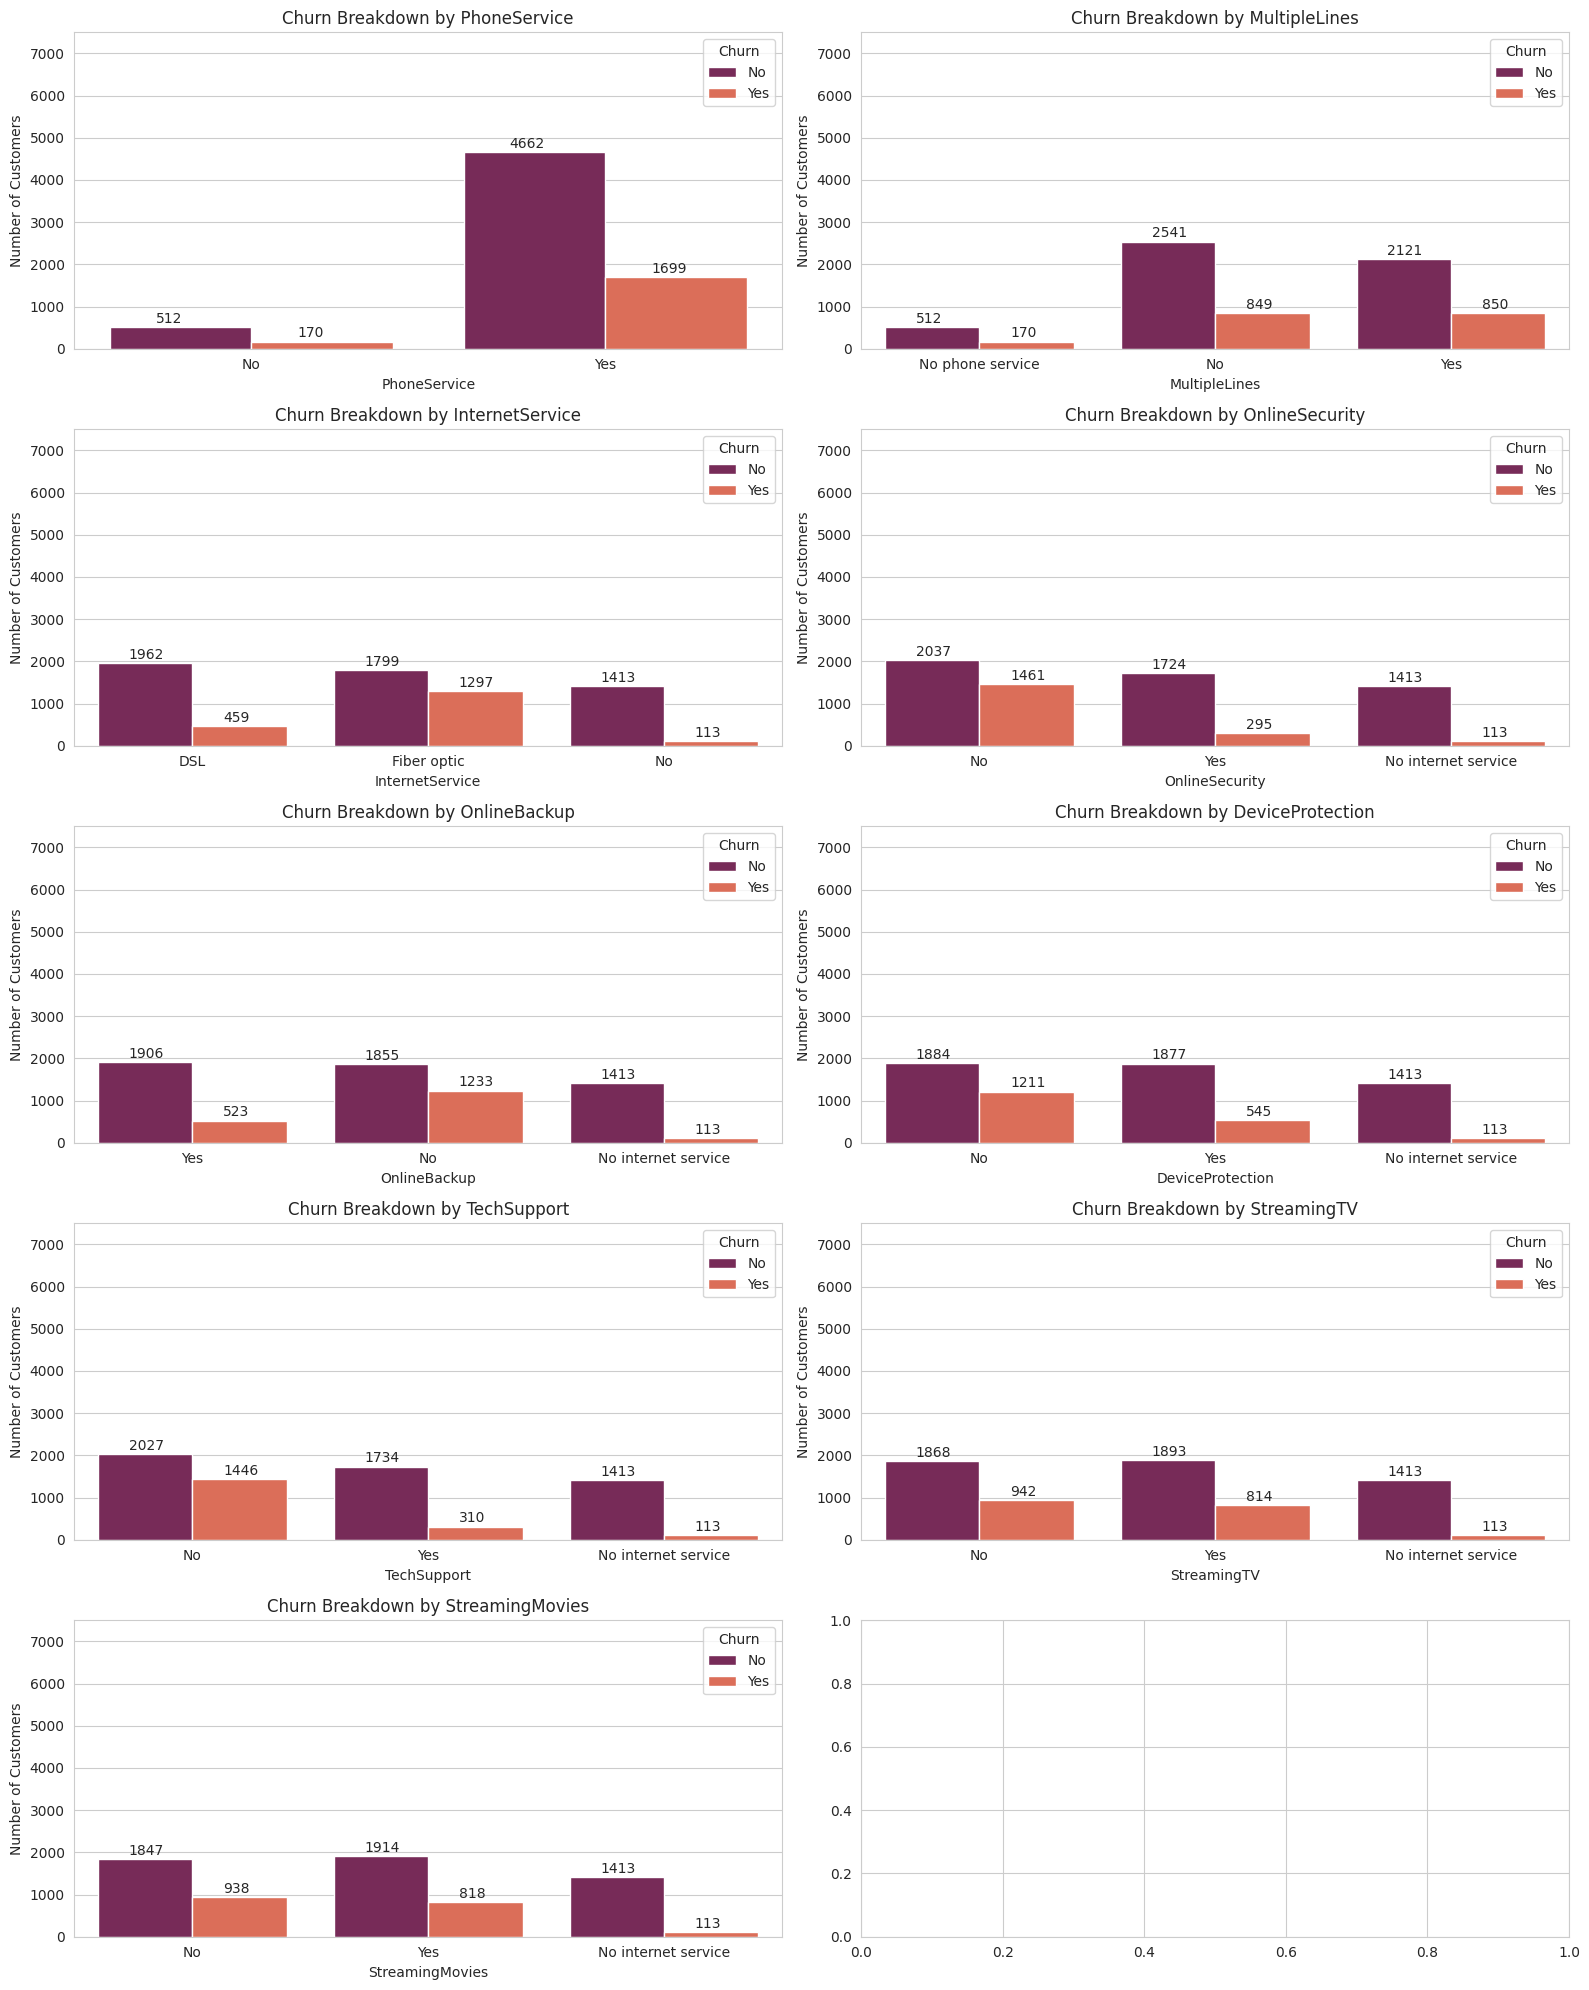

In [275]:
fig,axes=plt.subplots(5,2,figsize=(16,20))
for i,feat in enumerate(s_feats):
    ax=axes.flatten()[i]
    sns.countplot(data=df,x=feat,hue="Churn",palette="rocket",ax=ax)
    ax.set_xlabel(feat)
    ax.set_ylabel("Number of Customers")
    ax.set_ylim(0,7500)
    ax.set_title(f"Churn Breakdown by {feat}")
    for p in ax.patches:
        height=int(p.get_height())
        if height>0:
            ax.annotate((height),(p.get_x()+0.13,height+100))
plt.tight_layout()
plt.show()

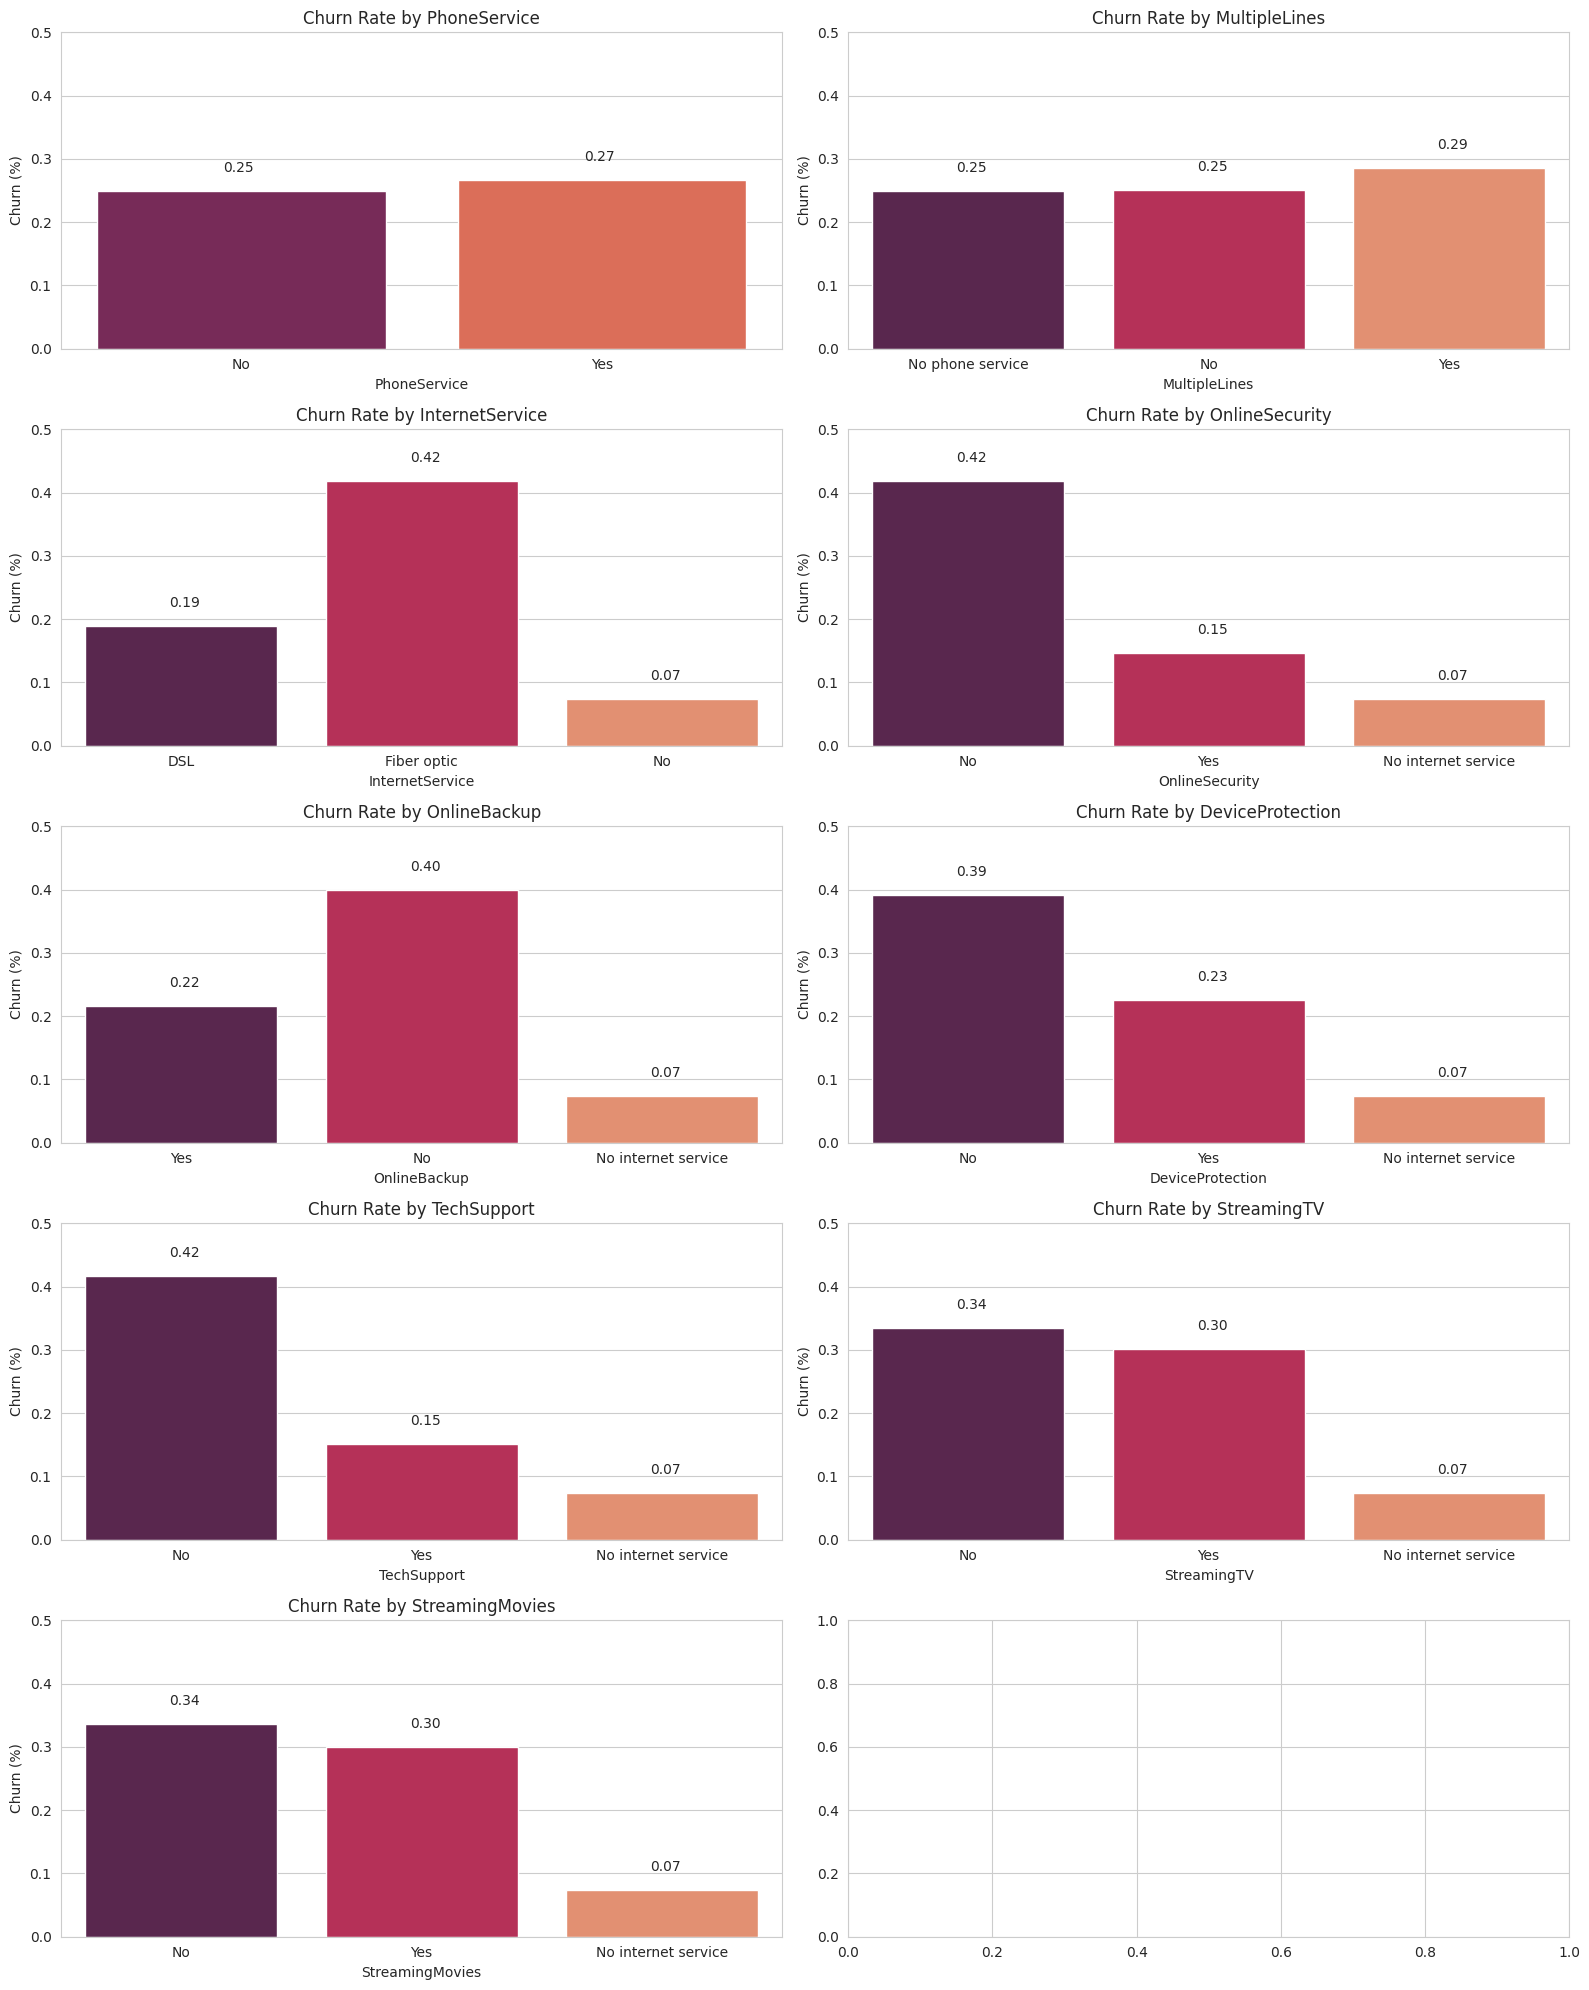

In [276]:
fig,axes=plt.subplots(5,2,figsize=(16,20))
for i,feat in enumerate(s_feats):
    ax=axes.flatten()[i]
    sns.barplot(data=df_temp,x=feat,y="Churn_num",hue=feat,palette="rocket",legend=False,ax=ax,errorbar=None)
    ax.set_xlabel(feat)
    ax.set_ylabel("Churn (%)")
    ax.set_ylim(0,0.5)
    ax.set_title(f"Churn Rate by {feat}")
    for p in ax.patches:
        ax.annotate("%.2f" %(p.get_height()), (p.get_x()+0.35,p.get_height()+0.03))
plt.tight_layout()
plt.show()

We can see that:
- Phone service: phone service does not affect churn rates significantly
- Multiple lines: having multiple lines does not affect churn rates significantly, but we can note that there is a slightly larger rate of churning for customers with multiple lines
- Internet service: Customers with fibre optic are far more likely to churn than any other internet service. Customers with DSL are more likely to churn than customers who do not have an internet plan
- Device protection: Customers without device protection are more likely to churn than any other customer, and customers with device protection are more likely to churn than those without any internet plan
- Tech support: Customers who do not have tech support are far more likely to churn than those who do not.
- Streaming TV: Customers who do or don't stream TV (with internet service) are almost equally likely to churn as one another, and much more likely to churn than those without internet service
- Streaming movies: Customers who do or don't stream movies (with internet service) are almost equally likely to churn as one another, and much more likely to churn than those without internet service

### Account Information Features (Categorical)

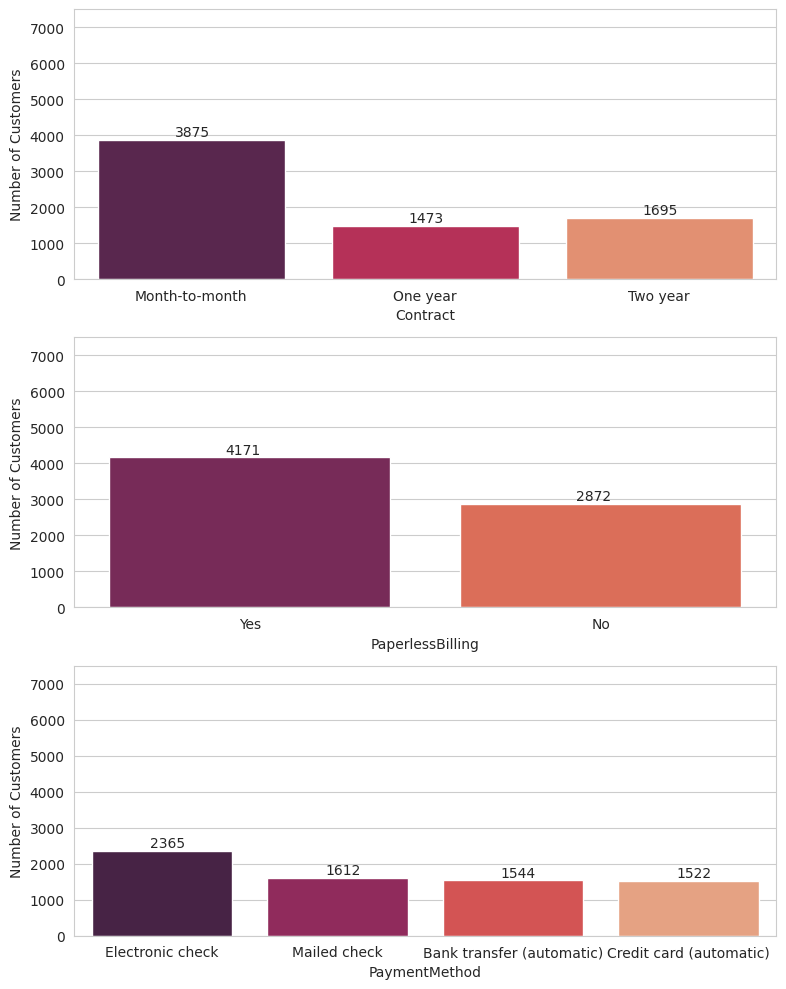

In [277]:
fig,axes=plt.subplots(3,1,figsize=(8,10))
for i,feat in enumerate(a_cat_feats):
    ax=axes.flatten()[i]
    sns.countplot(data=df,x=feat,hue=feat,palette="rocket",legend=False,ax=ax)
    ax.set_xlabel(feat)
    ax.set_ylabel("Number of Customers")
    ax.set_ylim(0,7500)
    for p in ax.patches:
        ax.annotate((int(p.get_height())),(p.get_x()+0.33,p.get_height()+100))
plt.tight_layout()
plt.show()

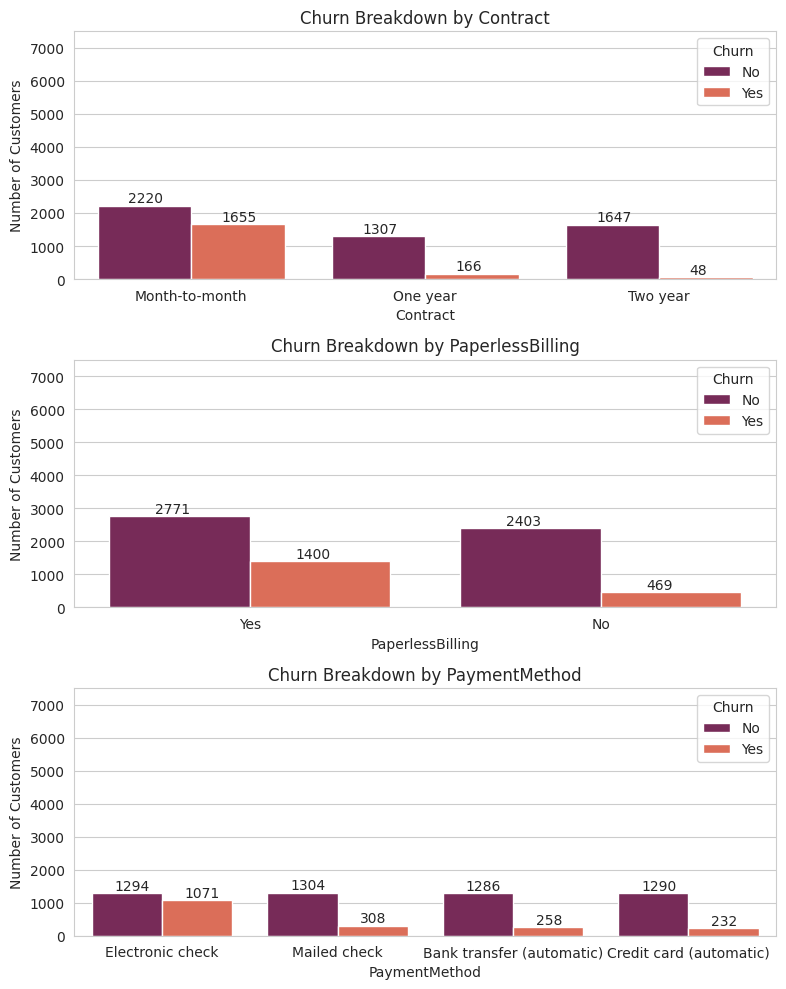

In [278]:
fig,axes=plt.subplots(3,1,figsize=(8,10))
for i,feat in enumerate(a_cat_feats):
    ax=axes.flatten()[i]
    sns.countplot(data=df,x=feat,hue="Churn",palette="rocket",ax=ax)
    ax.set_xlabel(feat)
    ax.set_ylabel("Number of Customers")
    ax.set_ylim(0,7500)
    ax.set_title(f"Churn Breakdown by {feat}")
    for p in ax.patches:
        height=int(p.get_height())
        if height>0:
            ax.annotate((height),(p.get_x()+0.13,height+100))
plt.tight_layout()
plt.show()

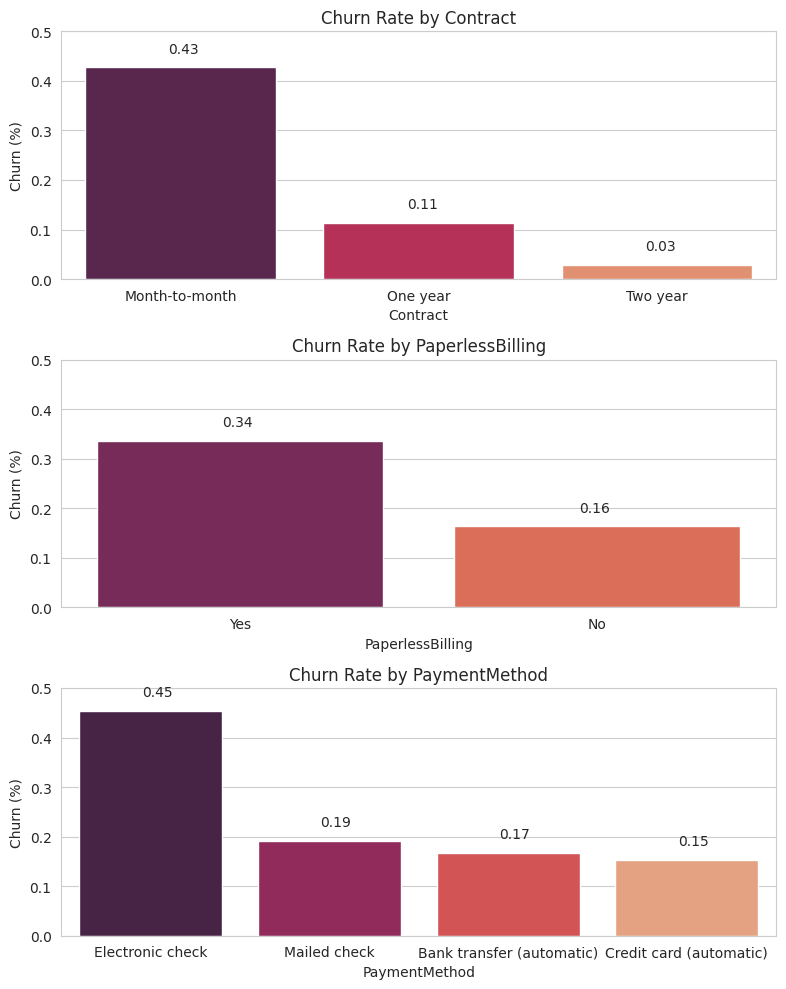

In [279]:
fig,axes=plt.subplots(3,1,figsize=(8,10))
for i,feat in enumerate(a_cat_feats):
    ax=axes.flatten()[i]
    sns.barplot(data=df_temp,x=feat,y="Churn_num",hue=feat,palette="rocket",legend=False,ax=ax,errorbar=None)
    ax.set_xlabel(feat)
    ax.set_ylabel("Churn (%)")
    ax.set_ylim(0,0.5)
    ax.set_title(f"Churn Rate by {feat}")
    for p in ax.patches:
        ax.annotate("%.2f" %(p.get_height()), (p.get_x()+0.35,p.get_height()+0.03))
plt.tight_layout()
plt.show()

From this we can see:
- Contract: Customers with month-to-month contracts are far more likely to churn than one-year contracts, who are more likely to churn than those with two year contracts
- Paperless billing: Customers with paperless billing are around twice as likely to churn than those without
- Payment method: Customers who pay with electronic check are far more likely to churn than other forms of payment, which are around equally as likely as each other to churn

### Account Information Features (Numerical)

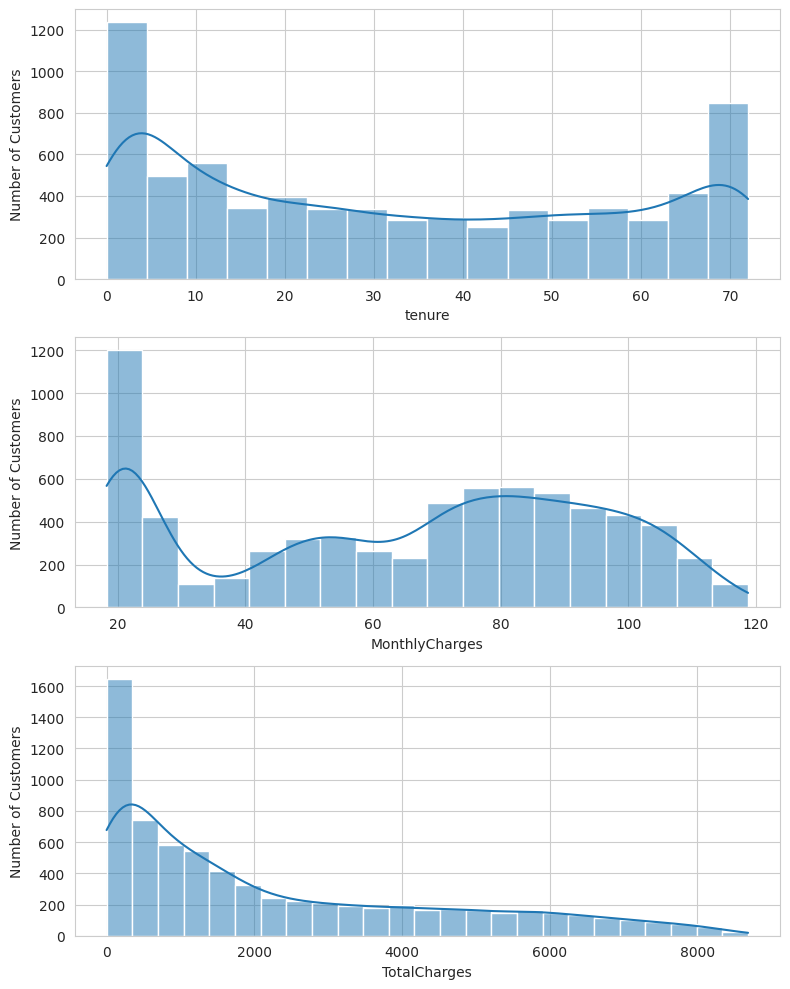

In [280]:
fig,axes=plt.subplots(3,1,figsize=(8,10))
for i,feat in enumerate(a_num_feats):
    ax=axes.flatten()[i]
    sns.histplot(df.loc[:,feat],ax=ax,kde=True)
    ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

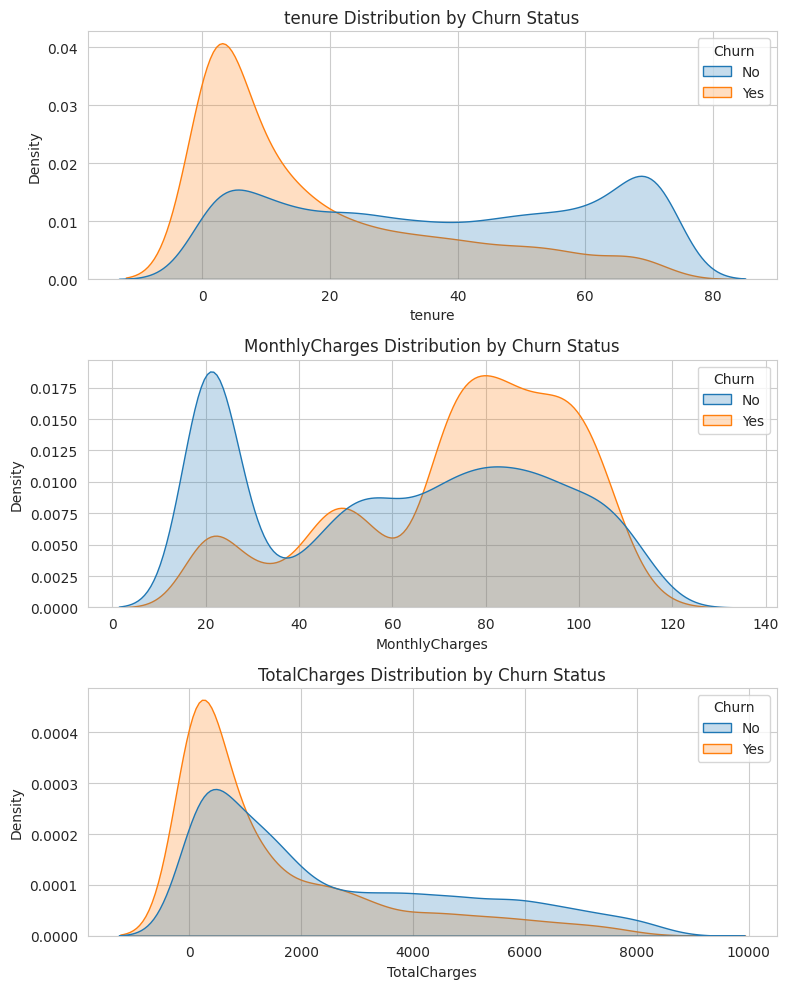

In [281]:
fig,axes=plt.subplots(3,1,figsize=(8,10))
for i,feat in enumerate(a_num_feats):
    ax=axes.flatten()[i]
    sns.kdeplot(data=df,x=feat,hue="Churn",fill=True,ax=ax,common_norm=False,palette="tab10")
    ax.set_title(f"{feat} Distribution by Churn Status")
plt.tight_layout()
plt.show()

From this we can see:
- Tenure: there are a lot of customers who churn in the first months
- Monthly charges: many customers churn when monthly charges are high
- Total charges: churned customers tend to have lower total costs, likely due to shorter tenure

## Preprocessing

Now that we understand the data, let us prepare it for modelling.

In [282]:
X=df.drop(columns=["customerID","Churn"])
y=(df["Churn"]=="Yes").astype(int)

cat_feats=X.select_dtypes(include="object").columns.tolist()
num_feats=X.select_dtypes(exclude="object").columns.tolist()
print("Categorical columns: ",cat_feats)
print("Numerical columns: ",num_feats)

Categorical columns:  ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns:  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [283]:
X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)
print("Train shape:",X_train.shape)
print("Validation shape:",X_valid.shape)
print("Train churn rate:%.3f"%y_train.mean())
print("Validation churn rate:%.3f"%y_valid.mean())

Train shape: (5634, 19)
Validation shape: (1409, 19)
Train churn rate:0.265
Validation churn rate:0.265


In [284]:
preprocessor=ColumnTransformer(transformers=[
    ("cat",OneHotEncoder(handle_unknown="ignore",drop="if_binary"),cat_feats),
    ("num","passthrough",num_feats),
])

## Modelling

We will train and compare three classifiers:
- Decision tree: a single tree
- Random forest: an ensemble of trees
- XGBoost: a gradient-boosted ensemble

Since we have an imbalanced target we use class weighting so the models do not simply predict "No" for every customer, and we compare them using precision, recall, F1, and ROC AUC rather than accuracy alone.

Rather than judging each model on a single train/test split which can be noisy, especially with an imbalanced minority class, we use 5-fold stratified cross-validation on the training set to get a more reliable estimate of performance before touching the validation set at all. For XGBoost specifically, we also use early stopping so that instead of guessing a fixed number of boosting rounds, we hold out a validation set and let XGBoost stop adding trees once validation loss stops improving, which helps avoid both under and overfitting.

First, we check how stable each model's performance is using 5-fold stratified cross-validation on the training set alone (`X_valid` stays untouched). This gives a mean and standard deviation for ROC AUC per model, rather than a single number that could just be luck of the split.

In [285]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)

cv_models={
    "Decision Tree":DecisionTreeClassifier(random_state=RANDOM_STATE,max_depth=6,class_weight="balanced"),
    "Random Forest":RandomForestClassifier(random_state=RANDOM_STATE,n_estimators=400,max_depth=10,class_weight="balanced",n_jobs=-1),
    "XGBoost":XGBClassifier(random_state=RANDOM_STATE,n_estimators=400,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,eval_metric="logloss"),
}

cv_results={}
for name,clf in cv_models.items():
    pipe=Pipeline([("preprocessor",preprocessor),("classifier",clf)])
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring="roc_auc",n_jobs=-1)
    cv_results[name]={"CV ROC AUC (mean)":scores["test_score"].mean(),"CV ROC AUC (std)":scores["test_score"].std()}

cv_results_df=pd.DataFrame(cv_results).T.sort_values("CV ROC AUC (mean)",ascending=False)
cv_results_df

,CV ROC AUC (mean),CV ROC AUC (std)
Random Forest,0.844,0.009
XGBoost,0.841,0.010
Decision Tree,0.818,0.006


For the final models, Decision Tree and Random Forest are fit on the full training set as before. XGBoost is handled separately just below, since early stopping eeds its own small validation split.

In [286]:
scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()

models={
    "Decision Tree":DecisionTreeClassifier(random_state=RANDOM_STATE,max_depth=6,class_weight="balanced"),
    "Random Forest":RandomForestClassifier(random_state=RANDOM_STATE,n_estimators=400,max_depth=10,class_weight="balanced",n_jobs=-1),
}

In [287]:
fitted_models={}
results={}
for name,clf in models.items():
    pipe=Pipeline([("preprocessor",preprocessor),("classifier",clf)])
    pipe.fit(X_train,y_train)
    y_pred=pipe.predict(X_valid)
    y_proba=pipe.predict_proba(X_valid)[:,1]

    results[name]={
        "Precision":precision_score(y_valid,y_pred),
        "Recall":recall_score(y_valid,y_pred),
        "F1":f1_score(y_valid,y_pred),
        "ROC AUC":roc_auc_score(y_valid,y_proba)
    }
    fitted_models[name]=pipe
results_df=pd.DataFrame(results).T.sort_values("ROC AUC",ascending=False)
results_df

,Precision,Recall,F1,ROC AUC
Random Forest,0.556,0.709,0.623,0.840
Decision Tree,0.508,0.791,0.619,0.829


Now we add XGBoost, using early stopping instead of a fixed number of trees. We carve a small validation split out of the training set (separate from `X_valid`, which stays reserved for the final comparison) and let XGBoost stop adding trees once performance on that split stops improving.

In [288]:
X_tr_fit,X_tr_es,y_tr_fit,y_tr_es=train_test_split(
    X_train,y_train,test_size=0.2,random_state=RANDOM_STATE,stratify=y_train
)

xgb_preprocessor=ColumnTransformer(transformers=[
    ("cat",OneHotEncoder(handle_unknown="ignore",drop="if_binary"),cat_feats),
    ("num","passthrough",num_feats),
]).fit(X_tr_fit)

xgb_clf=XGBClassifier(
    random_state=RANDOM_STATE,n_estimators=2000,max_depth=4,learning_rate=0.05,
    subsample=0.8,colsample_bytree=0.8,scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",early_stopping_rounds=50,
)
xgb_clf.fit(
    xgb_preprocessor.transform(X_tr_fit),y_tr_fit,
    eval_set=[(xgb_preprocessor.transform(X_tr_es),y_tr_es)],
    verbose=False,
)
print("XGBoost stopped at %d trees (best iteration)"%xgb_clf.best_iteration)

fitted_models["XGBoost"]=Pipeline([("preprocessor",xgb_preprocessor),("classifier",xgb_clf)])

y_pred=fitted_models["XGBoost"].predict(X_valid)
y_proba=fitted_models["XGBoost"].predict_proba(X_valid)[:,1]
results["XGBoost"]={
    "Precision":precision_score(y_valid,y_pred),
    "Recall":recall_score(y_valid,y_pred),
    "F1":f1_score(y_valid,y_pred),
    "ROC AUC":roc_auc_score(y_valid,y_proba),
}

results_df=pd.DataFrame(results).T.sort_values("ROC AUC",ascending=False)
results_df

XGBoost stopped at 244 trees (best iteration)


,Precision,Recall,F1,ROC AUC
XGBoost,0.523,0.775,0.624,0.841
Random Forest,0.556,0.709,0.623,0.840
Decision Tree,0.508,0.791,0.619,0.829


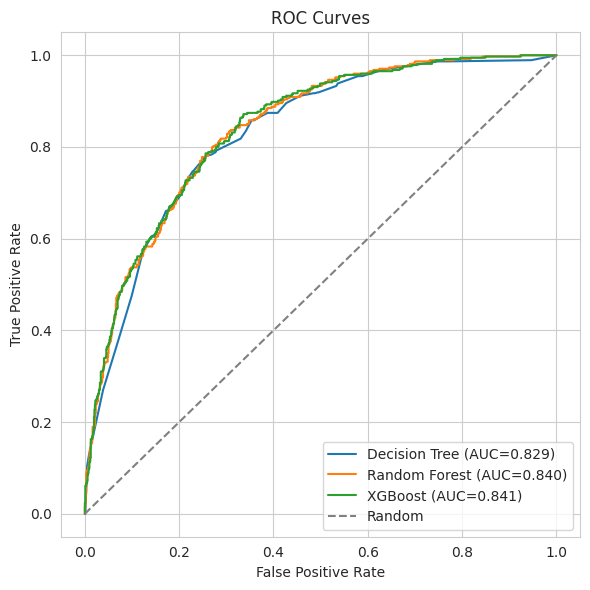

In [289]:
plt.figure(figsize=(6,6))
for name,pipe in fitted_models.items():
    y_proba=pipe.predict_proba(X_valid)[:,1]
    fpr,tpr,_=roc_curve(y_valid,y_proba)
    auc=roc_auc_score(y_valid,y_proba)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],linestyle="--",color="grey",label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

XGBoost achieves the highest ROC AUC, closely followed by Random Forest with the single Decision Tree lagging behind both ensembles. We use the best model by ROC AUC for the detailed evaluation below.

Best model: XGBoost
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.82      1035
       Churn       0.52      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



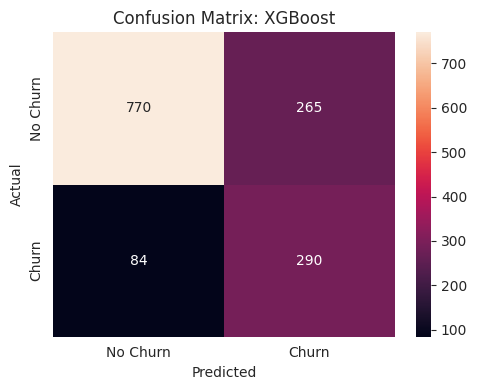

In [290]:
best_name=results_df.index[0]
best_pipe=fitted_models[best_name]
print("Best model:",best_name)

y_pred=best_pipe.predict(X_valid)

print(classification_report(y_valid,y_pred,target_names=["No Churn","Churn"]))

cm=confusion_matrix(y_valid,y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="rocket",
            xticklabels=["No Churn","Churn"],yticklabels=["No Churn","Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix: {best_name}")
plt.tight_layout()
plt.show()

## Explainability

We also want to understand why churn happens so that retention efforts can be targeted. We use the tree-based models' built-in feature importances and cross-check them against the Random Forest so the conclusions are not artifacts of a single model.

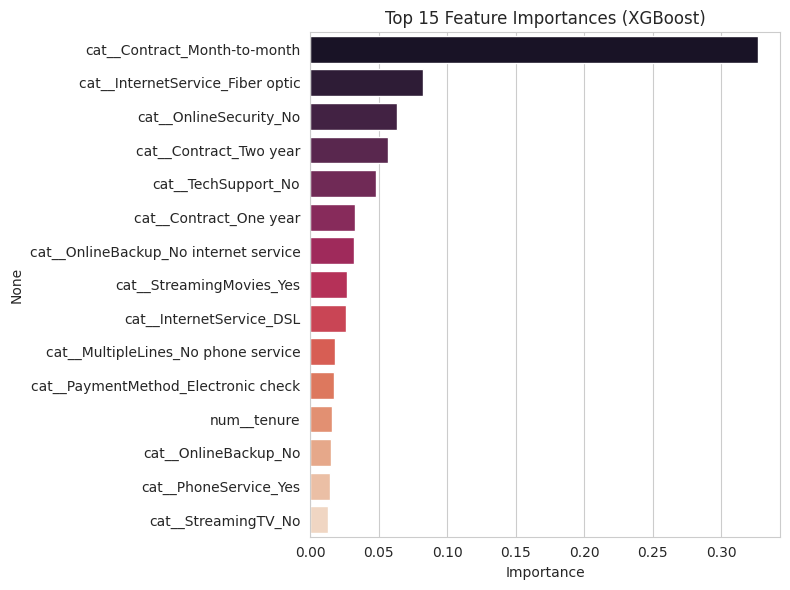

In [291]:
feature_names=best_pipe.named_steps["preprocessor"].get_feature_names_out()
importances=best_pipe.named_steps["classifier"].feature_importances_

feat_importance=(
    pd.Series(importances,index=feature_names)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8,6))
sns.barplot(x=feat_importance.values,y=feat_importance.index,
            hue=feat_importance.index,palette="rocket",legend=False)
plt.xlabel("Importance")
plt.title(f"Top 15 Feature Importances ({best_name})")
plt.tight_layout()
plt.show()

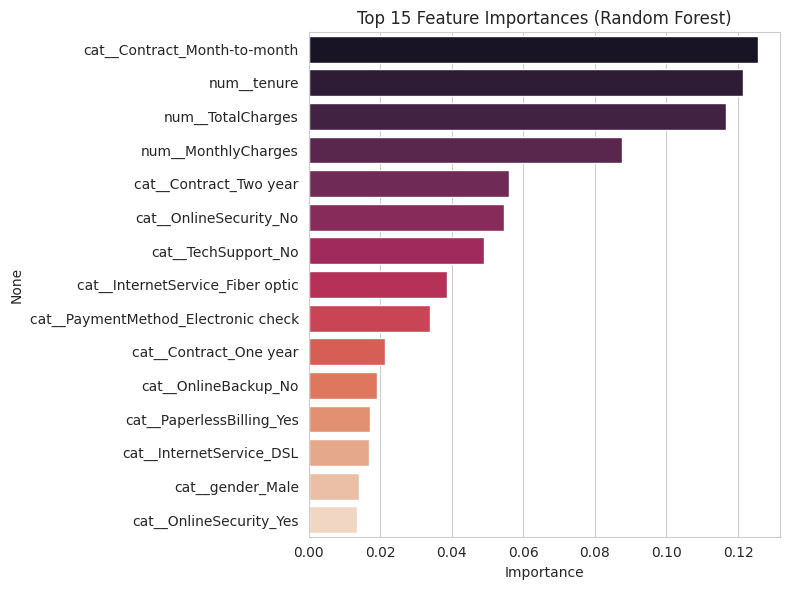

In [292]:
rf_pipe=fitted_models["Random Forest"]
rf_importances=rf_pipe.named_steps["classifier"].feature_importances_
rf_feat_importance=(
    pd.Series(rf_importances,index=feature_names)
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8,6))
sns.barplot(x=rf_feat_importance.values,y=rf_feat_importance.index,
            hue=rf_feat_importance.index,palette="rocket",legend=False)
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

Across both models, some of the features consistently ranked most important line up with what we saw in the EDA, like contract type, tenure, etc.

## Conclusion
Recommendations:
- incentivise month-to-month customers to move to one or two-year contract, since this was the largest churn driver
- target retention efforts to newer customers
- encourage users to set up automated payments, since electronic checks seemed to be a large driver when there were other automated options which had less churning rate